In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

In [2]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

In [3]:
print("Train:", train_df.shape)
print("Validation:", valid_df.shape)
print("Test:", test_df.shape)

Train: (7010, 11)
Validation: (1502, 11)
Test: (1503, 11)


In [4]:
train_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,disease,path,width,height
0,HAM_0006887,ISIC_0029500,akiec,histo,45.0,male,face,Actinic Keratosis,HAM10000_images_part_2\ISIC_0029500.jpg,600,450
1,HAM_0002717,ISIC_0031789,bcc,histo,75.0,male,face,Basal Cell Carcinoma,HAM10000_images_part_2\ISIC_0031789.jpg,600,450
2,HAM_0000310,ISIC_0032386,nv,follow_up,40.0,male,upper extremity,Melanocytic Nevus,HAM10000_images_part_2\ISIC_0032386.jpg,600,450
3,HAM_0005381,ISIC_0025153,mel,histo,45.0,female,lower extremity,Melanoma,HAM10000_images_part_1\ISIC_0025153.jpg,600,450
4,HAM_0004569,ISIC_0031495,bkl,histo,40.0,male,upper extremity,Benign Keratosis,HAM10000_images_part_2\ISIC_0031495.jpg,600,450


In [5]:
train_df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'disease', 'path', 'width', 'height'],
      dtype='str')

In [6]:
encoder = LabelEncoder()
train_df["label"] = encoder.fit_transform(train_df["disease"])
valid_df["label"] = encoder.transform(valid_df["disease"])
test_df["label"] = encoder.transform(test_df["disease"])

In [7]:
mapping = dict(zip(encoder.classes_,encoder.transform(encoder.classes_)))
print(mapping)

{'Actinic Keratosis': np.int64(0), 'Basal Cell Carcinoma': np.int64(1), 'Benign Keratosis': np.int64(2), 'Dermatofibroma': np.int64(3), 'Melanocytic Nevus': np.int64(4), 'Melanoma': np.int64(5), 'Vascular Lesion': np.int64(6)}


In [8]:
IMG_HEIGHT = 224
IMG_WIDTH = 224

In [9]:
def load_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    return image

In [10]:
img = load_image(train_df.iloc[0]["path"])
print(img.shape)

(224, 224, 3)


In [11]:
def normalize(image):
    image = image / 255.0
    return image

In [12]:
def preprocess(path):
    image = load_image(path)
    image = image / 255.0
    return image

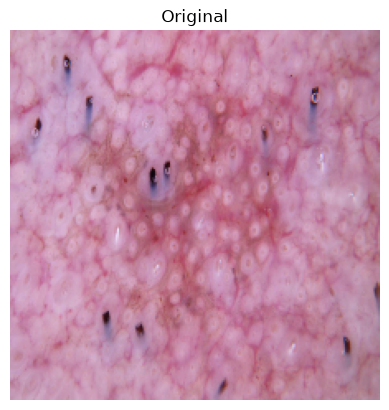

In [13]:
img = load_image(train_df.iloc[0]["path"])

plt.imshow(tf.cast(img, tf.uint8))
plt.title("Original")
plt.axis("off")
plt.show()

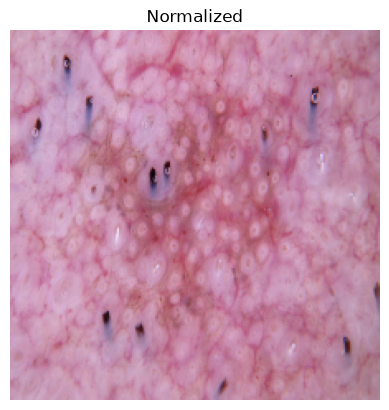

In [14]:
img = preprocess(train_df.iloc[0]["path"])

plt.imshow(img)
plt.title("Normalized")
plt.axis("off")
plt.show()

In [15]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0228093].


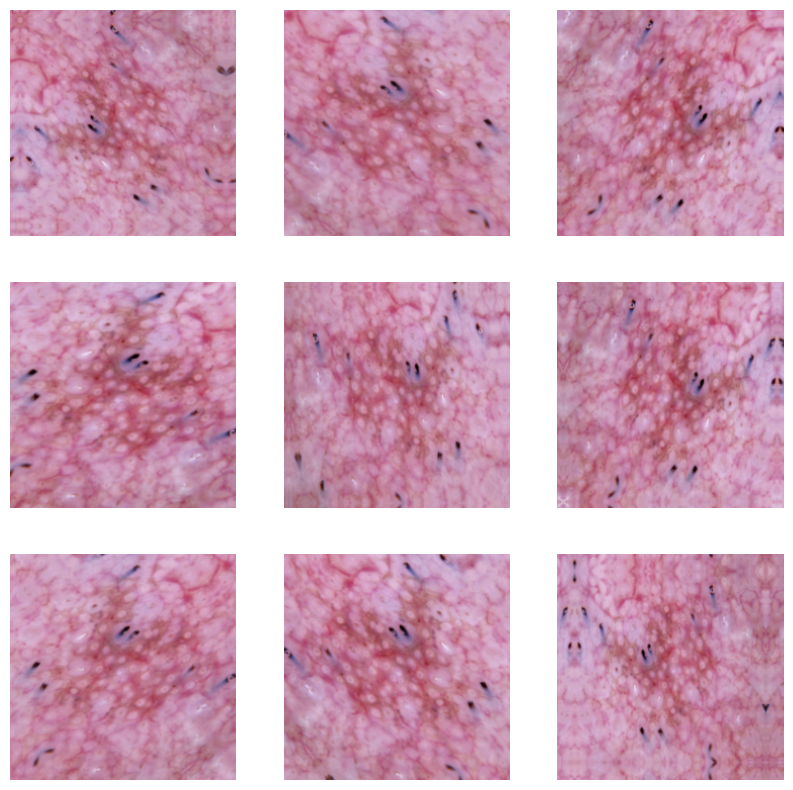

In [16]:
img = preprocess(train_df.iloc[0]["path"])
img = tf.expand_dims(img, 0)
plt.figure(figsize=(10,10))
for i in range(9):
    augmented = data_augmentation(img)
    plt.subplot(3,3,i+1)
    plt.imshow(augmented[0])
    plt.axis("off")
plt.show()

In [17]:
train_df["disease"].value_counts()

disease
Melanocytic Nevus       4693
Melanoma                 779
Benign Keratosis         769
Basal Cell Carcinoma     360
Actinic Keratosis        229
Vascular Lesion           99
Dermatofibroma            81
Name: count, dtype: int64

In [18]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

In [19]:
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(4.37305053025577), 1: np.float64(2.7817460317460316), 2: np.float64(1.3022478172023035), 3: np.float64(12.36331569664903), 4: np.float64(0.21338772031292808), 5: np.float64(1.285530900421786), 6: np.float64(10.115440115440116)}


In [20]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["path"], train_df["label"])
)

In [21]:
valid_ds = tf.data.Dataset.from_tensor_slices(
    (valid_df["path"], valid_df["label"])
)

In [22]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["path"], test_df["label"])
)

In [23]:
def process(path, label):
    image = load_image(path)
    image = image / 255.0
    return image, label

In [24]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
train_ds = (
    train_ds
    .map(process, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
)
valid_ds = (
    valid_ds
    .map(process, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
)
test_ds = (
    test_ds
    .map(process, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
)

In [25]:
def augment(images, labels):
    images = data_augmentation(images, training=True)
    return images, labels
train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE)

In [26]:
train_ds = train_ds.map(augment)

In [27]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [28]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [29]:
import joblib

joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']